## Imports and Functions

In [1]:
!uv pip install matplotlib

Using Python 3.12.3 environment at: code/.venvs/ML
Resolved 11 packages in 250ms                                        
Prepared 7 packages in 302ms                                             
Installed 7 packages in 2.09s                               
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.63.0
 + kiwisolver==1.5.0
 + matplotlib==3.11.1
 + pillow==12.3.0
 + pyparsing==3.3.2


In [3]:
import polars as pl
from polars import selectors as cs
import numpy as np
import altair as alt
import xgboost as xgb
import json
from pathlib import Path
import wandb
from wandb.integration.xgboost import WandbCallback
#import cupy as cp
pl.Config.set_tbl_rows(100)

polars.config.Config

In [33]:
def create_ctr(df, cols):
    df_ctr = (
        df
        .group_by(cols)
        .agg(
            pl.col('Label').len().alias('count'),
            pl.col('Label').sum().alias('clicks'),
            pl.col('Label').mean().alias('ctr'),
        )
        .with_columns(
            diff = pl.col('ctr') - pl.col('clicks').sum()/pl.col('count').sum(),
            margin =1.96*(pl.col('ctr')*(1-pl.col('ctr'))/pl.col('count')).sqrt()
        )
        .with_columns(
            margin_n  = -pl.col('margin'),
            delta = pl.col('diff').abs()/pl.col('margin')
        )
        .sort('count', descending=True)
    )
    return df_ctr



def get_data(config):
    train, valid = load_data(config['sample_every'])
    n_ints = 13
    ints = [f"I{i}" for i in range(1,n_ints+1)]
    n_cats = 26
    cats = [f"C{i}" for i in range(1,n_cats+1)]
    train = fill_missing(train, cats, "missing")
    valid= fill_missing(valid, cats, "missing")
    cat_encode, gm = calc_cat_encode(train, config, cats)
    train = encode_cats(train, cat_encode, cats)
    valid = encode_cats(valid, cat_encode, cats)

    train_X, train_y = get_data_XY(train)
    valid_X, valid_y = get_data_XY(valid)
    return train_X, train_y, valid_X, valid_y

    
def load_data(sample_every):
    data_dir = Path("../data/Criteo")
    train = pl.scan_parquet(data_dir / "train.parquet", row_index_name='Row').filter(pl.col('Row').mod(sample_every)==0)
    valid = pl.scan_parquet(data_dir /"valid.parquet")
    return train, valid


def fill_missing(df, cols, missing_val="missing"):
    df = df.with_columns(pl.col(cols).fill_null(missing_val))
    return df


def transform_cat(df, cols, label_col, cutoff, pseudo_count):
    df_ctr = (
        df
        .group_by(cols)
        .agg(
            pl.col(label_col).len().alias('count'),
            pl.col(label_col).sum().alias('clicks'),
            pl.col(label_col).mean().alias('ctr'),
        )
    )
    rest = df_ctr.filter(pl.col('count')< cutoff).select(['count','clicks']).sum()
    # rest is now row vector
    rest = rest.with_columns(ctr = pl.col('clicks')/pl.col('count'))

    df_ctr = df_ctr.filter(pl.col('count')>= cutoff)

    global_mean = df.select(label_col).mean().collect().item(0,0)
    ctr_smooth = (pl.col('clicks') + global_mean * pseudo_count)/(pl.col('count') + pseudo_count)
    df_ctr = df_ctr.with_columns(
        ctr_smooth_diff = ctr_smooth - pl.lit(global_mean)
    ).sort('ctr_smooth_diff', descending=True)
    rest = rest.with_columns(ctr_smooth = ctr_smooth)
    return df_ctr, rest, global_mean


def calc_cat_encode(df, config, cats):
    cat_encode = {}
    for col in cats: 
        cat_ctrs, rest_ctr, gm = transform_cat(df, col, 'Label', cutoff=config['cat_cutoff'], pseudo_count=config['cat_pseudo_count'])
        cat_encode[col] = pl.concat((cat_ctrs.collect(),rest_ctr.collect()),how='diagonal')
        # print(col, cat_encode[col].shape)
    return cat_encode, gm


def encode_cats(df, cat_encode, cats):
    for cat in cats:
        df = df.join(cat_encode[cat].lazy().rename({'ctr_smooth_diff': f'{cat}_encode'}).select([cat, f'{cat}_encode']),how='left', on = cat).drop(cat)
    df = df.with_columns(cs.ends_with("_encode").fill_null(0))
    return df


def get_data_XY(data):
    data_X = data.drop(['Row','Label'],strict=False).select(cs.starts_with("I") | cs.ends_with("_encode")|cs.starts_with("ar_")).collect()
    data_y = data.select('Label').collect().to_series()
    return data_X, data_y


def get_tree_statistics(model):
    booster = model.get_booster()
    df = pl.from_pandas(booster.trees_to_dataframe())

    lam = float(json.loads(booster.save_config())["learner"]["gradient_booster"]["tree_train_param"]["lambda"])
    eta = float(json.loads(booster.save_config())["learner"]["gradient_booster"]["tree_train_param"]["eta"])
    df = df.with_columns(H = pl.col("Cover"))                  # hessian sum, valid for every row
    is_leaf = pl.col("Feature") == "Leaf"
    df = df.with_columns(G = pl.when(is_leaf).then( - pl.col("Gain")* pl.col("H") + lam)/eta)
    tdfs = {}
    for tree_id, tdf in df.sort("Node", descending=True).group_by("Tree"):

        print(tree_id)
        g = dict(zip(tdf["ID"], tdf["G"]))

        intermediate_node = tdf.filter(~is_leaf)
        for row in intermediate_node.iter_rows(named=True):
            g[row["ID"]] = g[row["Yes"]] + g[row["No"]]   # missing already folds into Yes/No
        tdf = (
            tdf
            .with_columns(G = pl.col("ID").replace_strict(g))
            .with_columns(Metric = pl.col("G")**2/(pl.col("H") + lam))

        )
        metric = dict(zip(tdf["ID"], tdf["Metric"]))
        tdf = (
            tdf
            .with_columns( pl.col(["Yes", "No"]).replace_strict(metric).name.prefix("Metric_"))
            .with_columns(Gain_Expected = pl.col("Metric_Yes") + pl.col("Metric_No") - pl.col("Metric"))
        )

        tdfs[tree_id] = tdf
    df = pl.concat(tdfs.values())
    return df

import functools
import operator
def create_expression(pairs):
    return functools.reduce(
        operator.and_,
        (pl.col(col) == val for col, val in pairs),
    )

def parse_frequent(filename):
    df = (
        pl.scan_csv(filename,has_header=False, schema={"text": pl.String}).select(
            pl.col('text')
            .str.split(" ")
        ).with_columns(
            support = pl.col("text").list[-1].str.strip_chars("()").cast(pl.Float64)/100,
            text = (
                pl.col("text")
                .list.head(pl.col("text").list.len()-1)
                .list.eval(pl.element().str.split(":"))
                #.list.to_struct(upper_bound=5)
            )
        ).with_columns(
            rules = 
                pl.col('text').map_elements(create_expression, pl.Object)
        )
    )
    return df

def parse_association(filename):
    # Label1: <- X X X (Y, Y)
    regex = r"Label:1 <- (?P<items>[^(]+) \((?P<support>[0-9.]+), (?P<confidence>[0-9.]+)\)"
    df = (
        pl.scan_csv(filename,has_header=False, schema={"text": pl.String}, separator="|").select(
            pl.col('text')
            .str.extract_groups(regex)
        ).unnest('text')
        .with_columns(pl.col("items").str.split(" "))
        .with_columns(
            pl.col(["support", "confidence"]).cast(pl.Float64)/100,
            pl.col('items')
                .list.eval(pl.element().str.split(":"))
        )
        .with_columns(
            rules = 
                pl.col('items').map_elements(create_expression, pl.Object)
        )
    )
    return df



In [34]:
df = get_tree_statistics(clf)

(15,)
(3,)
(12,)
(30,)
(27,)
(0,)
(9,)
(21,)
(24,)
(6,)
(18,)
(54,)
(48,)
(36,)
(39,)
(57,)
(42,)
(33,)
(51,)
(60,)
(45,)
(63,)
(66,)
(16,)
(10,)
(4,)
(28,)
(22,)
(7,)
(13,)
(1,)
(19,)
(31,)
(25,)
(55,)
(58,)
(46,)
(52,)
(64,)
(40,)
(49,)
(37,)
(61,)
(34,)
(43,)
(67,)
(5,)
(26,)
(2,)
(8,)
(20,)
(29,)
(32,)
(14,)
(11,)
(23,)
(17,)
(35,)
(44,)
(65,)
(50,)
(47,)
(59,)
(62,)
(56,)
(53,)
(41,)
(38,)


In [36]:
df.tail()

Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category,H,G,Metric,Metric_Yes,Metric_No,Gain_Expected
i64,i64,str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
38,4,"""38-4""","""I12""",30.0,"""38-9""","""38-10""","""38-10""",16.892731,16378.7744,null,16378.7744,-390.40503,9.305708,1.223872,24.974566,16.892731
38,3,"""38-3""","""I9""",25.0,"""38-7""","""38-8""","""38-8""",22.563644,33973.0469,null,33973.0469,855.352043,21.535517,0.01412,44.085042,22.563645
38,2,"""38-2""","""C13_encode""",0.263704,"""38-5""","""38-6""","""38-6""",12.347521,5541.41113,null,5541.41113,-366.655251,24.26026,16.252312,20.355467,12.347519
38,1,"""38-1""","""I11""",3.0,"""38-3""","""38-4""","""38-3""",26.547916,50351.8203,null,50351.8203,464.947014,4.293305,21.535517,9.305708,26.547919
38,0,"""38-0""","""C14_encode""",0.115403,"""38-1""","""38-2""","""38-2""",28.380714,55893.2305,null,55893.2305,98.291762,0.172852,4.293305,24.26026,28.380713


In [10]:
booster = clf.get_booster()
df = pl.from_pandas(booster.trees_to_dataframe())

lam = float(json.loads(booster.save_config())["learner"]["gradient_booster"]["tree_train_param"]["lambda"])


In [11]:
eta = float(json.loads(booster.save_config())["learner"]["gradient_booster"]["tree_train_param"]["eta"])

In [12]:
eta

0.100000001

In [35]:
tree_df = get_tree_statistics(clf)

(161,)
(399,)
(551,)
(557,)
(24,)
(280,)
(286,)
(426,)
(402,)
(149,)
(21,)
(27,)
(533,)
(146,)
(18,)
(30,)
(36,)
(143,)
(527,)
(155,)
(134,)
(271,)
(292,)
(295,)
(39,)
(268,)
(274,)
(539,)
(167,)
(536,)
(545,)
(408,)
(0,)
(432,)
(137,)
(530,)
(405,)
(411,)
(265,)
(554,)
(6,)
(298,)
(420,)
(548,)
(283,)
(414,)
(152,)
(301,)
(277,)
(33,)
(289,)
(396,)
(429,)
(158,)
(3,)
(423,)
(12,)
(170,)
(560,)
(417,)
(164,)
(563,)
(542,)
(140,)
(15,)
(9,)
(60,)
(441,)
(566,)
(462,)
(66,)
(310,)
(596,)
(575,)
(48,)
(304,)
(465,)
(456,)
(185,)
(453,)
(435,)
(602,)
(75,)
(54,)
(209,)
(51,)
(176,)
(587,)
(581,)
(316,)
(57,)
(182,)
(444,)
(340,)
(194,)
(191,)
(331,)
(322,)
(206,)
(593,)
(63,)
(337,)
(45,)
(590,)
(69,)
(78,)
(203,)
(450,)
(197,)
(334,)
(325,)
(447,)
(200,)
(313,)
(72,)
(179,)
(438,)
(569,)
(572,)
(584,)
(471,)
(307,)
(173,)
(599,)
(459,)
(468,)
(42,)
(328,)
(578,)
(188,)
(319,)
(245,)
(504,)
(81,)
(96,)
(352,)
(108,)
(221,)
(248,)
(605,)
(477,)
(215,)
(84,)
(361,)
(364,)
(87,)
(376,)
(498,)

In [44]:
z1.head(20)

Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category,H,G
i64,i64,str,str,f64,str,str,str,f64,f64,f64,f64,f64
0,223882,"""0-223882""","""Leaf""",null,null,null,null,0.064939,1.5245837,null,1.5245837,-0.099004
0,223881,"""0-223881""","""Leaf""",null,null,null,null,-0.002196,6.479481,null,6.479481,0.014232
0,223880,"""0-223880""","""Leaf""",null,null,null,null,-0.002196,3.23974,null,3.23974,0.007116
0,223879,"""0-223879""","""Leaf""",null,null,null,null,0.04245,32.016258,null,32.016258,-1.359089
0,223878,"""0-223878""","""Leaf""",null,null,null,null,0.078057,1.5245837,null,1.5245837,-0.119004
0,223877,"""0-223877""","""Leaf""",null,null,null,null,-0.000653,1.5245837,null,1.5245837,0.000996
0,223876,"""0-223876""","""C18_encode""",0.06579,"""0-223881""","""0-223882""","""0-223882""",13.906538,8.004065,null,8.004065,-0.084772
0,223875,"""0-223875""","""I5""",7862.0,"""0-223879""","""0-223880""","""0-223880""",14.660919,35.255997,null,35.255997,-1.351973
0,223874,"""0-223874""","""Leaf""",null,null,null,null,0.025584,11.053232,null,11.053232,-0.282781


## Load data

In [7]:
%%time
config = {'sample_every': 100, 'cat_cutoff': 25, 'cat_pseudo_count':16}
train_X, train_y, valid_X, valid_y = get_data(config)


CPU times: user 3min 16s, sys: 33.5 s, total: 3min 50s
Wall time: 31.2 s


In [5]:
ar = parse_association("train_sample_10_associations.txt").collect()

In [6]:
ar_rules = {f"ar_{i}": ar_rule for i, ar_rule in enumerate(ar.get_column("rules").to_list())}

25% CTR 36 million rows originally

In [4]:
train_X.head()

I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,ar_0,ar_1,ar_2,ar_3,ar_4,ar_5,ar_6,ar_7,ar_8,ar_9,ar_10,ar_11,ar_12,ar_13,ar_14,ar_15,ar_16,ar_17,ar_18,ar_19,ar_20,ar_21,ar_22,ar_23,…,ar_986,ar_987,ar_988,ar_989,ar_990,ar_991,ar_992,ar_993,ar_994,ar_995,ar_996,C1_encode,C2_encode,C3_encode,C4_encode,C5_encode,C6_encode,C7_encode,C8_encode,C9_encode,C10_encode,C11_encode,C12_encode,C13_encode,C14_encode,C15_encode,C16_encode,C17_encode,C18_encode,C19_encode,C20_encode,C21_encode,C22_encode,C23_encode,C24_encode,C25_encode,C26_encode
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,…,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,6,6,6,421,109,1,7,107,0,1,null,6,true,true,false,false,false,true,true,false,false,false,true,true,true,false,false,false,true,true,false,false,false,true,true,false,…,false,false,false,false,false,false,false,false,false,false,false,0.000482,0.400711,0.030535,0.030535,-0.000114,0.000138,-0.076507,0.00021,0.014648,-0.038614,-0.006371,0.030535,-0.006371,0.019741,0.400568,0.030535,-0.071724,0.400711,0.012808,0.012808,0.030535,-0.008032,0.014706,0.030535,0.012808,0.012808
null,76,5,null,46200,null,null,7,null,null,null,0,null,false,false,false,false,true,false,false,false,false,true,true,false,false,false,false,false,false,false,false,false,false,false,false,false,…,false,false,false,false,false,false,false,false,false,false,false,-0.00075,-0.008333,0.208172,0.208578,0.000251,-0.007512,0.0,0.00021,-0.130051,0.0,-0.002465,0.208172,0.003447,0.019741,-0.005305,0.208172,-0.010959,-0.023049,-0.025611,-0.035276,0.208172,-0.008032,-0.01183,0.011951,-0.021554,-0.015426
3,125,10,10,2,5,14,6,12,1,3,0,2,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,…,false,false,false,false,false,false,false,false,false,false,false,0.000482,-0.034307,0.077533,0.077533,0.000251,-0.036294,0.009531,0.00021,0.014648,-0.006456,0.009531,0.077533,0.009531,0.001132,0.004352,0.077533,0.053052,-0.023585,-0.02001,0.023188,0.077533,-0.008032,-0.013667,0.027317,-0.033197,0.028736
null,1,181,9,897,null,0,26,26,null,0,null,10,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,false,…,false,false,false,false,false,false,false,false,false,false,false,0.000482,-0.015214,0.0,0.0,0.000251,-0.003452,-0.082774,0.00021,0.014648,-0.054229,-0.085775,0.0,-0.097071,-0.03652,-0.042706,0.0,-0.11788,-0.015214,0.014186,-0.018883,0.0,-0.008032,-0.038024,0.0,0.105385,0.0
null,5,null,null,19658,33,2,9,33,null,1,0,null,true,true,false,false,false,true,true,false,false,false,true,false,false,false,false,false,false,false,false,false,false,false,false,false,…,false,false,false,false,false,false,false,false,false,false,false,-0.002129,0.278469,0.125563,0.277968,-0.000107,0.077065,-0.130596,0.00021,0.014648,-0.038614,0.001546,0.125563,0.001546,0.019741,0.312843,0.168973,-0.146772,0.278469,0.012808,0.012808,0.168973,-0.008032,0.014706,0.154341,0.012808,0.012808


In [14]:
train_X, train_y, valid_X, valid_y = get_data(config)

C1 (454, 6)
C2 (530, 6)
C3 (9280, 6)
C4 (11601, 6)
C5 (129, 6)
C6 (14, 6)
C7 (8561, 6)
C8 (217, 6)
C9 (4, 6)
C10 (10332, 6)
C11 (4087, 6)
C12 (9504, 6)
C13 (3006, 6)
C14 (27, 6)
C15 (5246, 6)
C16 (10304, 6)
C17 (11, 6)
C18 (2645, 6)
C19 (1326, 6)
C20 (5, 6)
C21 (9888, 6)
C22 (11, 6)
C23 (15, 6)
C24 (8298, 6)
C25 (52, 6)
C26 (6538, 6)


In [4]:
config["association_rules"]=150

In [5]:

train_X = (
    train_X
    .drop(
        [f"ar_{i}" for i in range(config["association_rules"],997)]
    ,strict=False)
)
valid_X = (
    valid_X
    .drop(
        [f"ar_{i}" for i in range(config["association_rules"],997)]
    ,strict=False)
)


In [19]:
train_X.shape

(18336247, 1036)

In [16]:
train_X.head()

I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,ar_0,ar_1,ar_2,ar_3,ar_4,ar_5,ar_6,ar_7,ar_8,ar_9,ar_10,ar_11,ar_12,ar_13,ar_14,ar_15,ar_16,ar_17,ar_18,ar_19,ar_20,ar_21,ar_22,ar_23,…,ar_29,ar_30,ar_31,ar_32,ar_33,ar_34,ar_35,ar_36,ar_37,ar_38,ar_39,C1_encode,C2_encode,C3_encode,C4_encode,C5_encode,C6_encode,C7_encode,C8_encode,C9_encode,C10_encode,C11_encode,C12_encode,C13_encode,C14_encode,C15_encode,C16_encode,C17_encode,C18_encode,C19_encode,C20_encode,C21_encode,C22_encode,C23_encode,C24_encode,C25_encode,C26_encode
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,…,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,6,6,6,421,109,1,7,107,0,1,null,6,true,true,false,false,false,true,true,false,false,false,true,true,true,false,false,false,true,true,false,false,false,true,true,false,…,false,false,false,false,false,false,false,false,false,false,false,0.000291,0.366979,0.032083,0.032083,-0.000453,0.000886,-0.044054,0.000114,0.014614,-0.038606,0.011036,0.032083,0.011036,0.019725,0.368952,0.032083,-0.070745,0.366979,0.012977,0.012977,0.032083,-0.007806,0.014695,0.032083,0.012977,0.012977
null,4,16,null,5925,2,2,0,0,null,1,null,null,true,true,true,true,true,true,true,true,true,true,true,false,false,false,false,false,false,false,false,false,false,false,false,false,…,false,false,false,false,false,false,false,false,false,false,false,-0.000114,-0.032916,0.104131,0.104131,0.000152,0.000886,0.052607,0.000114,0.014614,0.054138,0.057622,0.104131,0.057622,0.137449,0.084826,0.104131,-0.033617,-0.022531,0.010531,-0.019003,0.104131,-0.007806,0.014695,-0.022217,-0.032288,-0.02674
null,76,5,null,46200,null,null,7,null,null,null,0,null,false,false,false,false,true,false,false,false,false,true,true,false,false,false,false,false,false,false,false,false,false,false,false,false,…,false,false,false,false,false,false,false,false,false,false,false,-0.000494,-0.007386,0.22246,0.222074,0.000152,-0.00728,-0.145393,0.000114,-0.129682,-0.040231,-0.002514,0.22246,0.001819,0.019725,-0.002515,0.22246,-0.010744,-0.021949,-0.025417,-0.034948,0.22246,-0.007806,-0.012507,0.013216,-0.020911,-0.012316
0,61,null,12,4243,189,5,7,141,0,2,null,19,true,true,true,true,true,true,true,true,true,true,true,false,false,false,false,false,false,false,false,false,false,false,false,true,…,true,true,true,true,true,true,true,true,true,false,false,-0.000494,0.114185,0.129215,0.129215,0.000152,0.012494,0.11085,0.000114,0.014614,0.047365,0.065313,0.129215,0.065044,0.019725,0.152111,0.129215,0.052689,0.114185,-0.025417,-0.034948,0.129215,-0.007806,-0.012507,0.117618,-0.020911,0.112376
3,125,10,10,2,5,14,6,12,1,3,0,2,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,true,…,true,true,true,true,true,true,true,true,true,true,true,0.000291,-0.032916,0.063902,0.063902,0.000152,-0.03647,0.00877,0.000114,0.014614,-0.000963,0.00877,0.063902,0.00877,0.000669,0.002409,0.063902,0.052689,-0.022531,-0.023578,0.022594,0.063902,-0.007806,-0.013848,0.01545,-0.032288,0.015566


In [13]:
train_X.shape, valid_X.shape

((3667250, 79), (4584062, 79))

In [7]:
%load_ext autoreload


In [8]:
%autoreload 2

## Train Model

In [8]:
with wandb.init(project="criteo_boost_gpu",config=config) as run:
    clf = xgb.XGBClassifier(device="gpu", tree_method="hist", early_stopping_rounds=10, min_child_weight=1.5, reg_lambda=0, gamma=8, n_estimators=200,learning_rate=.1,max_depth=60, callbacks=[WandbCallback(log_feature_importance=True)])
    clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
    tree_df = clf.get_booster().trees_to_dataframe()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/sean/.netrc.


wandb: Currently logged in as: seanv507 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[0]	validation_0-logloss:0.54234	validation_1-logloss:0.55253
[2]	validation_0-logloss:0.50743	validation_1-logloss:0.52978
[4]	validation_0-logloss:0.48426	validation_1-logloss:0.51490
[6]	validation_0-logloss:0.46797	validation_1-logloss:0.50478
[8]	validation_0-logloss:0.45612	validation_1-logloss:0.49775
[10]	validation_0-logloss:0.44686	validation_1-logloss:0.49272
[12]	validation_0-logloss:0.44008	validation_1-logloss:0.48915
[14]	validation_0-logloss:0.43445	validation_1-logloss:0.48653
[16]	validation_0-logloss:0.42975	validation_1-logloss:0.48449
[18]	validation_0-logloss:0.42586	validation_1-logloss:0.48293
[20]	validation_0-logloss:0.42267	validation_1-logloss:0.48180
[22]	validation_0-logloss:0.41983	validation_1-logloss:0.48090
[24]	validation_0-logloss:0.41753	validation_1-logloss:0.48021
[26]	validation_0-logloss:0.41541	validation_1-logloss:0.47956
[28]	validation_0-logloss:0.41361	validation_1-logloss:0.47897
[30]	validation_0-logloss:0.41208	validation_1-logloss:0.478

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
validation_0-logloss,█▇▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▆▅▅▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,57
best_score,0.47556
epoch,67


In [9]:
tree_df = clf.get_booster().trees_to_dataframe()


In [17]:
td.tail()

Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
i64,i64,str,str,f64,str,str,str,f64,f64,f64
36,95292,"""36-95292""","""I4""",4.0,"""36-95295""","""36-95296""","""36-95296""",2.85235,4.417055,null
36,95293,"""36-95293""","""Leaf""",null,null,null,null,0.144142,2.174225,null
36,95294,"""36-95294""","""Leaf""",null,null,null,null,0.027635,10.373088,null
36,95295,"""36-95295""","""Leaf""",null,null,null,null,0.056059,2.116359,null
36,95296,"""36-95296""","""Leaf""",null,null,null,null,-0.104799,2.3006959,null


In [14]:
td = pl.from_pandas(tree_df)

In [18]:
td.filter(pl.col("Feature")=="Leaf").describe()

statistic,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
str,f64,f64,str,str,f64,str,str,str,f64,f64,f64
"""count""",7.02363e6,7.02363e6,"""7023630""","""7023630""",0.0,"""0""","""0""","""0""",7.02363e6,7.02363e6,0.0
"""null_count""",0.0,0.0,"""0""","""0""",7.02363e6,"""7023630""","""7023630""","""7023630""",0.0,0.0,7.02363e6
"""mean""",12.012309,274442.748646,null,null,null,null,null,null,0.021487,6.866405,null
"""std""",9.152878,184290.001151,null,null,null,null,null,null,0.104485,32.895088,null
"""min""",0.0,39.0,"""0-10000""","""Leaf""",null,null,null,null,-0.27092,2.0,null
"""25%""",5.0,115495.0,null,null,null,null,null,null,-0.072635,2.523575,null
"""50%""",10.0,243232.0,null,null,null,null,null,null,0.014876,3.359483,null
"""75%""",18.0,414669.0,null,null,null,null,null,null,0.098401,5.0603447,null
"""max""",36.0,710654.0,"""9-99999""","""Leaf""",null,null,null,null,0.390313,8667.27051,null


### Association Rules

In [8]:
for n_rules in [30,20,10,5,4,3,2]:
    config["association_rules"]=n_rules
    print(n_rules)
    train_X = (
        train_X
        .drop(
            [f"ar_{i}" for i in range(config["association_rules"],997)]
        ,strict=False)
    )
    valid_X = (
        valid_X
        .drop(
            [f"ar_{i}" for i in range(config["association_rules"],997)]
        ,strict=False)
    )
    
    with wandb.init(project="criteo_boost_sample_ar_10",config=config) as run:
        clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=10, reg_lambda=0, gamma=10, n_estimators=200,learning_rate=.1,max_depth=60, callbacks=[WandbCallback(log_feature_importance=True)])
        clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
    #tree_df = clf.get_booster().trees_to_dataframe()

30


[0]	validation_0-logloss:0.54578	validation_1-logloss:0.54929
[2]	validation_0-logloss:0.51359	validation_1-logloss:0.52177
[4]	validation_0-logloss:0.49235	validation_1-logloss:0.50361
[6]	validation_0-logloss:0.47750	validation_1-logloss:0.49103
[8]	validation_0-logloss:0.46659	validation_1-logloss:0.48210
[10]	validation_0-logloss:0.45848	validation_1-logloss:0.47566
[12]	validation_0-logloss:0.45225	validation_1-logloss:0.47087
[14]	validation_0-logloss:0.44742	validation_1-logloss:0.46733
[16]	validation_0-logloss:0.44416	validation_1-logloss:0.46483
[18]	validation_0-logloss:0.44102	validation_1-logloss:0.46277
[20]	validation_0-logloss:0.43840	validation_1-logloss:0.46114
[22]	validation_0-logloss:0.43621	validation_1-logloss:0.45984
[24]	validation_0-logloss:0.43434	validation_1-logloss:0.45879
[26]	validation_0-logloss:0.43258	validation_1-logloss:0.45783
[28]	validation_0-logloss:0.43117	validation_1-logloss:0.45709
[30]	validation_0-logloss:0.42997	validation_1-logloss:0.456

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██
validation_0-logloss,█▆▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▄▄▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,111
best_score,0.44812
epoch,121


20


[0]	validation_0-logloss:0.54582	validation_1-logloss:0.54930
[2]	validation_0-logloss:0.51369	validation_1-logloss:0.52179
[4]	validation_0-logloss:0.49244	validation_1-logloss:0.50363
[6]	validation_0-logloss:0.47751	validation_1-logloss:0.49108
[8]	validation_0-logloss:0.46657	validation_1-logloss:0.48210
[10]	validation_0-logloss:0.45849	validation_1-logloss:0.47565
[12]	validation_0-logloss:0.45242	validation_1-logloss:0.47093
[14]	validation_0-logloss:0.44759	validation_1-logloss:0.46738
[16]	validation_0-logloss:0.44379	validation_1-logloss:0.46472
[18]	validation_0-logloss:0.44087	validation_1-logloss:0.46269
[20]	validation_0-logloss:0.43826	validation_1-logloss:0.46105
[22]	validation_0-logloss:0.43609	validation_1-logloss:0.45976
[24]	validation_0-logloss:0.43422	validation_1-logloss:0.45871
[26]	validation_0-logloss:0.43257	validation_1-logloss:0.45781
[28]	validation_0-logloss:0.43112	validation_1-logloss:0.45706
[30]	validation_0-logloss:0.42986	validation_1-logloss:0.456

...

[0]	validation_0-logloss:0.54590	validation_1-logloss:0.54929
[2]	validation_0-logloss:0.51387	validation_1-logloss:0.52177
[4]	validation_0-logloss:0.49265	validation_1-logloss:0.50361
[6]	validation_0-logloss:0.47773	validation_1-logloss:0.49103
[8]	validation_0-logloss:0.46686	validation_1-logloss:0.48207
[10]	validation_0-logloss:0.45879	validation_1-logloss:0.47564
[12]	validation_0-logloss:0.45255	validation_1-logloss:0.47086
[14]	validation_0-logloss:0.44777	validation_1-logloss:0.46735
[16]	validation_0-logloss:0.44399	validation_1-logloss:0.46470
[18]	validation_0-logloss:0.44095	validation_1-logloss:0.46267
[20]	validation_0-logloss:0.43837	validation_1-logloss:0.46107
[22]	validation_0-logloss:0.43622	validation_1-logloss:0.45977
[24]	validation_0-logloss:0.43479	validation_1-logloss:0.45886
[26]	validation_0-logloss:0.43366	validation_1-logloss:0.45815
[28]	validation_0-logloss:0.43214	validation_1-logloss:0.45736
[30]	validation_0-logloss:0.43076	validation_1-logloss:0.456

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
validation_0-logloss,█▆▄▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,111
best_score,0.4482
epoch,121


2


[0]	validation_0-logloss:0.54591	validation_1-logloss:0.54929
[2]	validation_0-logloss:0.51388	validation_1-logloss:0.52177
[4]	validation_0-logloss:0.49267	validation_1-logloss:0.50361
[6]	validation_0-logloss:0.47775	validation_1-logloss:0.49103
[8]	validation_0-logloss:0.46689	validation_1-logloss:0.48209
[10]	validation_0-logloss:0.45883	validation_1-logloss:0.47564
[12]	validation_0-logloss:0.45265	validation_1-logloss:0.47089
[14]	validation_0-logloss:0.44784	validation_1-logloss:0.46735
[16]	validation_0-logloss:0.44407	validation_1-logloss:0.46469
[18]	validation_0-logloss:0.44097	validation_1-logloss:0.46264
[20]	validation_0-logloss:0.43841	validation_1-logloss:0.46103
[22]	validation_0-logloss:0.43628	validation_1-logloss:0.45976
[24]	validation_0-logloss:0.43445	validation_1-logloss:0.45871
[26]	validation_0-logloss:0.43281	validation_1-logloss:0.45780
[28]	validation_0-logloss:0.43129	validation_1-logloss:0.45701
[30]	validation_0-logloss:0.43005	validation_1-logloss:0.456

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
validation_0-logloss,█▇▅▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▄▄▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,112
best_score,0.44816
epoch,122


In [6]:
with wandb.init(project="criteo_boost_sample_ar_10",config=config) as run:
    clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=10, reg_lambda=0, gamma=10, n_estimators=200,learning_rate=.1,max_depth=60, callbacks=[WandbCallback(log_feature_importance=True)])
    clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
    #tree_df = clf.get_booster().trees_to_dataframe()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: seanv507 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[0]	validation_0-logloss:0.54658	validation_1-logloss:0.54936
[2]	validation_0-logloss:0.51464	validation_1-logloss:0.52183
[4]	validation_0-logloss:0.49317	validation_1-logloss:0.50364
[6]	validation_0-logloss:0.47808	validation_1-logloss:0.49104
[8]	validation_0-logloss:0.46711	validation_1-logloss:0.48208
[10]	validation_0-logloss:0.45895	validation_1-logloss:0.47562
[12]	validation_0-logloss:0.45271	validation_1-logloss:0.47088
[14]	validation_0-logloss:0.44786	validation_1-logloss:0.46734
[16]	validation_0-logloss:0.44402	validation_1-logloss:0.46468
[18]	validation_0-logloss:0.44093	validation_1-logloss:0.46266
[20]	validation_0-logloss:0.43832	validation_1-logloss:0.46102
[22]	validation_0-logloss:0.43638	validation_1-logloss:0.45978
[24]	validation_0-logloss:0.43450	validation_1-logloss:0.45872
[26]	validation_0-logloss:0.43290	validation_1-logloss:0.45789
[28]	validation_0-logloss:0.43162	validation_1-logloss:0.45716
[30]	validation_0-logloss:0.43017	validation_1-logloss:0.456

best_iteration,▁
best_score,▁
epoch,▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇██
validation_0-logloss,█▇▆▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,109
best_score,0.44828
epoch,119


In [5]:
with wandb.init(project="criteo_boost_sample_ar_10",config=config) as run:
    clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=10, reg_lambda=0, gamma=10, n_estimators=200,learning_rate=.1,max_depth=60, callbacks=[WandbCallback(log_feature_importance=True)])
    clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
    #tree_df = clf.get_booster().trees_to_dataframe()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: seanv507 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[0]	validation_0-logloss:0.54658	validation_1-logloss:0.55046
[2]	validation_0-logloss:0.51524	validation_1-logloss:0.52455
[4]	validation_0-logloss:0.49449	validation_1-logloss:0.50750
[6]	validation_0-logloss:0.47992	validation_1-logloss:0.49579
[8]	validation_0-logloss:0.46932	validation_1-logloss:0.48750
[10]	validation_0-logloss:0.46142	validation_1-logloss:0.48155
[12]	validation_0-logloss:0.45528	validation_1-logloss:0.47713
[14]	validation_0-logloss:0.45052	validation_1-logloss:0.47387
[16]	validation_0-logloss:0.44671	validation_1-logloss:0.47143
[18]	validation_0-logloss:0.44358	validation_1-logloss:0.46952
[20]	validation_0-logloss:0.44097	validation_1-logloss:0.46799
[22]	validation_0-logloss:0.43883	validation_1-logloss:0.46686
[24]	validation_0-logloss:0.43697	validation_1-logloss:0.46588
[26]	validation_0-logloss:0.43532	validation_1-logloss:0.46506
[28]	validation_0-logloss:0.43384	validation_1-logloss:0.46433
[30]	validation_0-logloss:0.43254	validation_1-logloss:0.463

Traceback (most recent call last):
  File "/tmp/ipykernel_6977/1118294670.py", line 4, in <module>
    tree_df = clf.get_booster().trees_to_dataframe()
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/workspace/code/.venvs/ML/lib/python3.12/site-packages/xgboost/core.py", line 3349, in trees_to_dataframe
    raise ValueError("Failed to parse model text dump.")
ValueError: Failed to parse model text dump.


best_iteration,▁
best_score,▁
epoch,▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇██
validation_0-logloss,█▆▅▄▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▆▅▅▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,88
best_score,0.45772
epoch,98


ValueError: Failed to parse model text dump.

In [ ]:
clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2, reg_lambda=0, gamma=0, n_estimators=20)
clf.fit(train_X, train_y, eval_set=[(valid_X, valid_y)],verbose=2,)
tree_df = clf.get_booster().trees_to_dataframe()

In [29]:
clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2, reg_lambda=0, gamma=10, n_estimators=150,learning_rate=.1,max_depth=20, callbacks=[WandbCallback(log_feature_importance=True)])
clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
tree_df = clf.get_booster().trees_to_dataframe()

[0]	validation_0-logloss:0.54783	validation_1-logloss:0.54985
[2]	validation_0-logloss:0.51779	validation_1-logloss:0.52291
[4]	validation_0-logloss:0.49773	validation_1-logloss:0.50511
[6]	validation_0-logloss:0.48349	validation_1-logloss:0.49273
[8]	validation_0-logloss:0.47309	validation_1-logloss:0.48390
[10]	validation_0-logloss:0.46533	validation_1-logloss:0.47752
[12]	validation_0-logloss:0.45940	validation_1-logloss:0.47279
[14]	validation_0-logloss:0.45478	validation_1-logloss:0.46924
[16]	validation_0-logloss:0.45112	validation_1-logloss:0.46658
[18]	validation_0-logloss:0.44818	validation_1-logloss:0.46453
[20]	validation_0-logloss:0.44570	validation_1-logloss:0.46286
[22]	validation_0-logloss:0.44361	validation_1-logloss:0.46152
[24]	validation_0-logloss:0.44188	validation_1-logloss:0.46044
[26]	validation_0-logloss:0.44034	validation_1-logloss:0.45951
[28]	validation_0-logloss:0.43899	validation_1-logloss:0.45872
[30]	validation_0-logloss:0.43781	validation_1-logloss:0.458

### Sweep

### Sweep

In [21]:
sweep_config = {
    "method": "grid", # try grid or random
    "metric": {
      "name": "validation_1-logloss",
      "goal": "minimize"   
    },
    "parameters": {
        "learning_rate": {
            "values": [0.1]
        },
        "gamma": {
            "values": [0,5,10,15]
        },
        "reg_lambda": {
            "values": [0,1,10]
        },
        "min_child_weight": {
            "values": [1,2,4,8,16]
        },
        
        "max_depth":{
            "values": [50, 55, 60, 65, 70, 75, 80]
        },
    }
}

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x733995093d70>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 732bc399a5a0, raw_cell="sweep_config = {
    "method": "grid", # try grid .." transformed_cell="sweep_config = {
    "method": "grid", # try grid .." store_history=True silent=False shell_futures=True cell_id=70cf6c0f-3ad2-4029-9567-0b2d38bb91a6>,),kwargs {}:


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x733995093d70>> (for post_run_cell), with arguments args (<ExecutionResult object at 732bc399ad20, execution_count=21 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 732bc399a5a0, raw_cell="sweep_config = {
    "method": "grid", # try grid .." transformed_cell="sweep_config = {
    "method": "grid", # try grid .." store_history=True silent=False shell_futures=True cell_id=70cf6c0f-3ad2-4029-9567-0b2d38bb91a6> result=None>,),kwargs {}:


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

In [15]:
sweep_id = wandb.sweep(sweep_config, project="criteo_boost_sweep_04")

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x733995093d70>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7327450c5250, raw_cell="sweep_id = wandb.sweep(sweep_config, project="crit.." transformed_cell="sweep_id = wandb.sweep(sweep_config, project="crit.." store_history=True silent=False shell_futures=True cell_id=51620901-95db-4f4b-aeab-581fb31514b2>,),kwargs {}:


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

Create sweep with ID: ozi2tmij
Sweep URL: https://wandb.ai/seanv507/criteo_boost_sweep_04/sweeps/ozi2tmij
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x733995093d70>> (for post_run_cell), with arguments args (<ExecutionResult object at 7327450c79b0, execution_count=15 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7327450c5250, raw_cell="sweep_id = wandb.sweep(sweep_config, project="crit.." transformed_cell="sweep_id = wandb.sweep(sweep_config, project="crit.." store_history=True silent=False shell_futures=True cell_id=51620901-95db-4f4b-aeab-581fb31514b2> result=None>,),kwargs {}:


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

In [12]:
sweep_id = wandb.sweep(sweep_config, project="criteo_boost_sweep")

Create sweep with ID: s15xvple
Sweep URL: https://wandb.ai/seanv507/criteo_boost_sweep/sweeps/s15xvple


In [9]:
sweep_id="17b17huq"

In [16]:
def train():
    config = {
        'sample_every': 4, 
        'cat_cutoff': 25, 
        'cat_pseudo_count':16,
        'tree_method': "hist", 
        'early_stopping_rounds': 10,
        'reg_lambda': 0, 
        'gamma': 10, 
        'n_estimators': 150,
        'learning_rate':.1,
        'max_depth':60,
    }

    with wandb.init(config=config) as run:
        config_data = {key: value for key,value in wandb.config.items() if key in ('sample_every', 'cat_cutoff', 'cat_pseudo_count')} 
        config_xgb = {key: value for key,value in wandb.config.items() if key not in ('sample_every', 'cat_cutoff', 'cat_pseudo_count')}
        config_xgb["device"]= "gpu"
        #train_X, train_y, valid_X, valid_y = get_data(config_data)
        clf = xgb.XGBClassifier(**config_xgb, callbacks=[WandbCallback(log_feature_importance=True)])
        clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
        tree_df = clf.get_booster().trees_to_dataframe()
    

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x733995093d70>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7327450ca8d0, raw_cell="def train():
    config = {
        'sample_every'.." transformed_cell="def train():
    config = {
        'sample_every'.." store_history=True silent=False shell_futures=True cell_id=9b47c413-699f-4262-9b0b-35d1b1a5fdfe>,),kwargs {}:


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x733995093d70>> (for post_run_cell), with arguments args (<ExecutionResult object at 7327450caf30, execution_count=16 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7327450ca8d0, raw_cell="def train():
    config = {
        'sample_every'.." transformed_cell="def train():
    config = {
        'sample_every'.." store_history=True silent=False shell_futures=True cell_id=9b47c413-699f-4262-9b0b-35d1b1a5fdfe> result=None>,),kwargs {}:


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

In [19]:
wandb.teardown()

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x733995093d70>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 733300c72a80, raw_cell="wandb.teardown()" transformed_cell="wandb.teardown()
" store_history=True silent=False shell_futures=True cell_id=d70d99eb-8c40-404d-9f86-743f85bfccd5>,),kwargs {}:


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x733995093d70>> (for post_run_cell), with arguments args (<ExecutionResult object at 733300c72480, execution_count=19 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 733300c72a80, raw_cell="wandb.teardown()" transformed_cell="wandb.teardown()
" store_history=True silent=False shell_futures=True cell_id=d70d99eb-8c40-404d-9f86-743f85bfccd5> result=None>,),kwargs {}:


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

In [17]:
wandb.agent(sweep_id, train, project="criteo_boost_sweep_04") # no count

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x733995093d70>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7327450c8650, raw_cell="wandb.agent(sweep_id, train, project="criteo_boost.." transformed_cell="wandb.agent(sweep_id, train, project="criteo_boost.." store_history=True silent=False shell_futures=True cell_id=6ed7c80c-3ca1-4e4b-a50f-6ef155721472>,),kwargs {}:


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

wandb: Agent Starting Run: 3sl6y2an with config:
wandb: 	gamma: 0
wandb: 	learning_rate: 0.1
wandb: 	max_depth: 50
wandb: 	min_child_weight: 1
wandb: 	reg_lambda: 0
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: 
wandb: 🚀 View run different-sweep-3 at: https://wandb.ai/seanv507/criteo_boost_sweep_03/runs/fag8durp
wandb: Find logs at: wandb/run-20260718_135456-fag8durp/logs


Traceback (most recent call last):
  File "/tmp/ipykernel_4276/776264601.py", line 21, in train
    clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 553, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1807, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 553, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/training.py", line 195, in train
    bst = cb_container.before_training(bst)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/callback.py", line 186, in before_training
    model = c.before_training(model=model)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.1

...

wandb: Ctrl + C detected. Stopping sweep.


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x733995093d70>> (for post_run_cell), with arguments args (<ExecutionResult object at 7327450cb050, execution_count=17 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7327450c8650, raw_cell="wandb.agent(sweep_id, train, project="criteo_boost.." transformed_cell="wandb.agent(sweep_id, train, project="criteo_boost.." store_history=True silent=False shell_futures=True cell_id=6ed7c80c-3ca1-4e4b-a50f-6ef155721472> result=None>,),kwargs {}:


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

[4]	validation_0-logloss:0.47257	validation_1-logloss:0.50737


Traceback (most recent call last):
Traceback (most recent call last):
  File "/tmp/ipykernel_4276/776264601.py", line 21, in train
    clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 553, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1807, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 553, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/training.py", line 201, in train
    if cb_container.after_iteration(bst, i, dtrain, evals):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/callback.py", line 268, in after_iteration
    ret = any(c.after_iteration(model, epoch, self.h

In [15]:
def train():
    config = {
        'sample_every': 1, 
        'cat_cutoff': 25, 
        'cat_pseudo_count':16,
        'tree_method': "hist", 
        'early_stopping_rounds': 10,
        'reg_lambda': 0, 
        'gamma': 10, 
        'n_estimators': 150,
        'learning_rate':.1,
        'max_depth':60,
    }

    with wandb.init(config=config) as run:
        config_data = {key: value for key,value in wandb.config.items() if key in ('sample_every', 'cat_cutoff', 'cat_pseudo_count')} 
        config_xgb = {key: value for key,value in wandb.config.items() if key not in ('sample_every', 'cat_cutoff', 'cat_pseudo_count')}
        train_X, train_y, valid_X, valid_y = get_data(config_data)
        clf = xgb.XGBClassifier(**config_xgb, callbacks=[WandbCallback(log_feature_importance=True)])
        clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
        tree_df = clf.get_booster().trees_to_dataframe()
    

In [ ]:
wandb.agent(sweep_id, train) # no count

wandb: Agent Starting Run: 1h8m3lys with config:
wandb: 	learning_rate: 0.1
wandb: 	max_depth: 50
wandb: 	subsample: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


[0]	validation_0-logloss:0.54558	validation_1-logloss:0.54885
[2]	validation_0-logloss:0.51329	validation_1-logloss:0.52073
[4]	validation_0-logloss:0.49213	validation_1-logloss:0.50219
[6]	validation_0-logloss:0.47707	validation_1-logloss:0.48932
[8]	validation_0-logloss:0.46612	validation_1-logloss:0.48018
[10]	validation_0-logloss:0.45790	validation_1-logloss:0.47351
[12]	validation_0-logloss:0.45164	validation_1-logloss:0.46860
[14]	validation_0-logloss:0.44681	validation_1-logloss:0.46498
[16]	validation_0-logloss:0.44299	validation_1-logloss:0.46223
[18]	validation_0-logloss:0.43991	validation_1-logloss:0.46011
[20]	validation_0-logloss:0.43726	validation_1-logloss:0.45842
[22]	validation_0-logloss:0.43509	validation_1-logloss:0.45708
[24]	validation_0-logloss:0.43327	validation_1-logloss:0.45600
[26]	validation_0-logloss:0.43163	validation_1-logloss:0.45506
[28]	validation_0-logloss:0.43013	validation_1-logloss:0.45426
[30]	validation_0-logloss:0.42879	validation_1-logloss:0.453

best_iteration,▁
best_score,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇██
validation_0-logloss,█▇▅▄▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▅▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,128
best_score,0.44442
epoch,138


wandb: Agent Starting Run: 1cqebxu4 with config:
wandb: 	learning_rate: 0.1
wandb: 	max_depth: 50
wandb: 	subsample: 0.5
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


[0]	validation_0-logloss:0.54740	validation_1-logloss:0.54923
[2]	validation_0-logloss:0.51719	validation_1-logloss:0.52147
[4]	validation_0-logloss:0.49710	validation_1-logloss:0.50314
[6]	validation_0-logloss:0.48305	validation_1-logloss:0.49045
[8]	validation_0-logloss:0.47288	validation_1-logloss:0.48142
[10]	validation_0-logloss:0.46574	validation_1-logloss:0.47500
[12]	validation_0-logloss:0.46000	validation_1-logloss:0.47014
[14]	validation_0-logloss:0.45556	validation_1-logloss:0.46650
[16]	validation_0-logloss:0.45209	validation_1-logloss:0.46376
[18]	validation_0-logloss:0.44936	validation_1-logloss:0.46168
[20]	validation_0-logloss:0.44710	validation_1-logloss:0.46001
[22]	validation_0-logloss:0.44524	validation_1-logloss:0.45868
[24]	validation_0-logloss:0.44362	validation_1-logloss:0.45758
[26]	validation_0-logloss:0.44262	validation_1-logloss:0.45684
[28]	validation_0-logloss:0.44138	validation_1-logloss:0.45603
[30]	validation_0-logloss:0.44030	validation_1-logloss:0.455

...

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▂▂▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇██
validation_0-logloss,█▇▅▅▅▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,149
best_score,0.44724
epoch,149


wandb: Agent Starting Run: s1b5iqgu with config:
wandb: 	learning_rate: 0.05
wandb: 	max_depth: 70
wandb: 	subsample: 0.3
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


[0]	validation_0-logloss:0.55835	validation_1-logloss:0.55896
[2]	validation_0-logloss:0.54051	validation_1-logloss:0.54209
[4]	validation_0-logloss:0.52620	validation_1-logloss:0.52859
[6]	validation_0-logloss:0.51451	validation_1-logloss:0.51758
[8]	validation_0-logloss:0.50485	validation_1-logloss:0.50850
[10]	validation_0-logloss:0.49676	validation_1-logloss:0.50093
[12]	validation_0-logloss:0.48993	validation_1-logloss:0.49457
[14]	validation_0-logloss:0.48412	validation_1-logloss:0.48919
[16]	validation_0-logloss:0.47916	validation_1-logloss:0.48463
[18]	validation_0-logloss:0.47493	validation_1-logloss:0.48075
[20]	validation_0-logloss:0.47129	validation_1-logloss:0.47744
[22]	validation_0-logloss:0.46811	validation_1-logloss:0.47458
[24]	validation_0-logloss:0.46536	validation_1-logloss:0.47213
[26]	validation_0-logloss:0.46294	validation_1-logloss:0.47001
[28]	validation_0-logloss:0.46083	validation_1-logloss:0.46816
[30]	validation_0-logloss:0.45895	validation_1-logloss:0.466

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇██
validation_0-logloss,█▇▇▆▆▄▄▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▇▅▄▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,149
best_score,0.44865
epoch,149


wandb: Agent Starting Run: dk15stho with config:
wandb: 	learning_rate: 0.2
wandb: 	max_depth: 50
wandb: 	subsample: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


In [18]:
for sample_every in (2,):
    for cat_cutoff in (1,2,4,8,16,32):
        config = {'sample_every': sample_every, 'cat_cutoff': 25, 'cat_pseudo_count':cat_cutoff}
        train_X, train_y, valid_X, valid_y = get_data(config)
        
        with wandb.init(project="criteo_boost_sample_cutoff",config=config) as run:
            clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2, reg_lambda=0, gamma=10, n_estimators=150,learning_rate=.1,max_depth=60, callbacks=[WandbCallback(log_feature_importance=True)])
            clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
            tree_df = clf.get_booster().trees_to_dataframe()

[0]	validation_0-logloss:0.54586	validation_1-logloss:0.54928
[2]	validation_0-logloss:0.51372	validation_1-logloss:0.52170
[4]	validation_0-logloss:0.49244	validation_1-logloss:0.50352
[6]	validation_0-logloss:0.47751	validation_1-logloss:0.49096
[8]	validation_0-logloss:0.46659	validation_1-logloss:0.48203
[10]	validation_0-logloss:0.45849	validation_1-logloss:0.47561
[12]	validation_0-logloss:0.45225	validation_1-logloss:0.47084
[14]	validation_0-logloss:0.44741	validation_1-logloss:0.46730
[16]	validation_0-logloss:0.44361	validation_1-logloss:0.46466
[18]	validation_0-logloss:0.44056	validation_1-logloss:0.46265
[20]	validation_0-logloss:0.43798	validation_1-logloss:0.46104
[22]	validation_0-logloss:0.43583	validation_1-logloss:0.45977
[24]	validation_0-logloss:0.43403	validation_1-logloss:0.45876
[26]	validation_0-logloss:0.43234	validation_1-logloss:0.45784
[28]	validation_0-logloss:0.43090	validation_1-logloss:0.45711
[30]	validation_0-logloss:0.42954	validation_1-logloss:0.456

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
validation_0-logloss,█▇▆▆▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▆▄▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,113
best_score,0.44846
epoch,115


[0]	validation_0-logloss:0.54587	validation_1-logloss:0.54929
[2]	validation_0-logloss:0.51378	validation_1-logloss:0.52173
[4]	validation_0-logloss:0.49246	validation_1-logloss:0.50354
[6]	validation_0-logloss:0.47749	validation_1-logloss:0.49095
[8]	validation_0-logloss:0.46663	validation_1-logloss:0.48204
[10]	validation_0-logloss:0.45854	validation_1-logloss:0.47559
[12]	validation_0-logloss:0.45231	validation_1-logloss:0.47083
[14]	validation_0-logloss:0.44749	validation_1-logloss:0.46730
[16]	validation_0-logloss:0.44372	validation_1-logloss:0.46468
[18]	validation_0-logloss:0.44061	validation_1-logloss:0.46262
[20]	validation_0-logloss:0.43800	validation_1-logloss:0.46100
[22]	validation_0-logloss:0.43584	validation_1-logloss:0.45972
[24]	validation_0-logloss:0.43405	validation_1-logloss:0.45869
[26]	validation_0-logloss:0.43253	validation_1-logloss:0.45783
[28]	validation_0-logloss:0.43108	validation_1-logloss:0.45707
[30]	validation_0-logloss:0.42963	validation_1-logloss:0.456

best_iteration,▁
best_score,▁
epoch,▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
validation_0-logloss,█▇▆▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▆▅▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,111
best_score,0.4484
epoch,113


[0]	validation_0-logloss:0.54591	validation_1-logloss:0.54929
[2]	validation_0-logloss:0.51380	validation_1-logloss:0.52172
[4]	validation_0-logloss:0.49249	validation_1-logloss:0.50352
[6]	validation_0-logloss:0.47753	validation_1-logloss:0.49093
[8]	validation_0-logloss:0.46667	validation_1-logloss:0.48201
[10]	validation_0-logloss:0.45859	validation_1-logloss:0.47557
[12]	validation_0-logloss:0.45234	validation_1-logloss:0.47075
[14]	validation_0-logloss:0.44756	validation_1-logloss:0.46726
[16]	validation_0-logloss:0.44377	validation_1-logloss:0.46463
[18]	validation_0-logloss:0.44097	validation_1-logloss:0.46266
[20]	validation_0-logloss:0.43834	validation_1-logloss:0.46104
[22]	validation_0-logloss:0.43614	validation_1-logloss:0.45974
[24]	validation_0-logloss:0.43427	validation_1-logloss:0.45868
[26]	validation_0-logloss:0.43267	validation_1-logloss:0.45783
[28]	validation_0-logloss:0.43114	validation_1-logloss:0.45701
[30]	validation_0-logloss:0.42982	validation_1-logloss:0.456

...

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
validation_0-logloss,█▆▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,112
best_score,0.44823
epoch,114


[0]	validation_0-logloss:0.54591	validation_1-logloss:0.54929
[2]	validation_0-logloss:0.51388	validation_1-logloss:0.52177
[4]	validation_0-logloss:0.49267	validation_1-logloss:0.50360
[6]	validation_0-logloss:0.47777	validation_1-logloss:0.49102
[8]	validation_0-logloss:0.46689	validation_1-logloss:0.48208
[10]	validation_0-logloss:0.45882	validation_1-logloss:0.47564
[12]	validation_0-logloss:0.45266	validation_1-logloss:0.47092
[14]	validation_0-logloss:0.44785	validation_1-logloss:0.46736
[16]	validation_0-logloss:0.44411	validation_1-logloss:0.46472
[18]	validation_0-logloss:0.44100	validation_1-logloss:0.46266
[20]	validation_0-logloss:0.43844	validation_1-logloss:0.46105
[22]	validation_0-logloss:0.43627	validation_1-logloss:0.45975
[24]	validation_0-logloss:0.43440	validation_1-logloss:0.45869
[26]	validation_0-logloss:0.43278	validation_1-logloss:0.45780
[28]	validation_0-logloss:0.43134	validation_1-logloss:0.45705
[30]	validation_0-logloss:0.43002	validation_1-logloss:0.456

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇███
validation_0-logloss,█▆▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▅▅▄▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,112
best_score,0.44817
epoch,114


[0]	validation_0-logloss:0.54601	validation_1-logloss:0.54936
[2]	validation_0-logloss:0.51410	validation_1-logloss:0.52187
[4]	validation_0-logloss:0.49298	validation_1-logloss:0.50374
[6]	validation_0-logloss:0.47815	validation_1-logloss:0.49120
[8]	validation_0-logloss:0.46734	validation_1-logloss:0.48228
[10]	validation_0-logloss:0.45972	validation_1-logloss:0.47593
[12]	validation_0-logloss:0.45353	validation_1-logloss:0.47117
[14]	validation_0-logloss:0.44870	validation_1-logloss:0.46760
[16]	validation_0-logloss:0.44508	validation_1-logloss:0.46496
[18]	validation_0-logloss:0.44198	validation_1-logloss:0.46292
[20]	validation_0-logloss:0.43943	validation_1-logloss:0.46131
[22]	validation_0-logloss:0.43722	validation_1-logloss:0.45999
[24]	validation_0-logloss:0.43535	validation_1-logloss:0.45893
[26]	validation_0-logloss:0.43363	validation_1-logloss:0.45796
[28]	validation_0-logloss:0.43218	validation_1-logloss:0.45720
[30]	validation_0-logloss:0.43089	validation_1-logloss:0.456

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██
validation_0-logloss,█▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▆▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,114
best_score,0.44823
epoch,116


In [51]:
with wandb.init(project="criteo_boost",config=config) as run:
    clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2, reg_lambda=0, gamma=12, n_estimators=150,learning_rate=.1,max_depth=70, callbacks=[WandbCallback(log_feature_importance=True)])
    clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
    tree_df = clf.get_booster().trees_to_dataframe()

[0]	validation_0-logloss:0.54811	validation_1-logloss:0.54986
[2]	validation_0-logloss:0.51877	validation_1-logloss:0.52301
[4]	validation_0-logloss:0.49930	validation_1-logloss:0.50528
[6]	validation_0-logloss:0.48561	validation_1-logloss:0.49294
[8]	validation_0-logloss:0.47572	validation_1-logloss:0.48417
[10]	validation_0-logloss:0.46841	validation_1-logloss:0.47782
[12]	validation_0-logloss:0.46286	validation_1-logloss:0.47314
[14]	validation_0-logloss:0.45859	validation_1-logloss:0.46960
[16]	validation_0-logloss:0.45524	validation_1-logloss:0.46694
[18]	validation_0-logloss:0.45258	validation_1-logloss:0.46489
[20]	validation_0-logloss:0.45036	validation_1-logloss:0.46322
[22]	validation_0-logloss:0.44845	validation_1-logloss:0.46184
[24]	validation_0-logloss:0.44709	validation_1-logloss:0.46083
[26]	validation_0-logloss:0.44582	validation_1-logloss:0.45997
[28]	validation_0-logloss:0.44452	validation_1-logloss:0.45909
[30]	validation_0-logloss:0.44343	validation_1-logloss:0.458

best_iteration,▁
best_score,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
validation_0-logloss,█▅▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,114
best_score,0.44921
epoch,116


In [52]:
with wandb.init(project="criteo_boost",config=config) as run:
    clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2, reg_lambda=0, gamma=12, n_estimators=150,learning_rate=.1,max_depth=70, callbacks=[WandbCallback(log_feature_importance=True)])
    clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
    tree_df = clf.get_booster().trees_to_dataframe()
with wandb.init(project="criteo_boost",config=config) as run:
    clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2, reg_lambda=0, gamma=10, n_estimators=150,learning_rate=.1,max_depth=70, callbacks=[WandbCallback(log_feature_importance=True)])
    clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
    tree_df = clf.get_booster().trees_to_dataframe()
with wandb.init(project="criteo_boost",config=config) as run:
    clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2, reg_lambda=0, gamma=10, n_estimators=150,learning_rate=.1,max_depth=80, callbacks=[WandbCallback(log_feature_importance=True)])
    clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
    tree_df = clf.get_booster().trees_to_dataframe()
with wandb.init(project="criteo_boost",config=config) as run:
    clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2, reg_lambda=0, gamma=10, n_estimators=150,learning_rate=.1,max_depth=90, callbacks=[WandbCallback(log_feature_importance=True)])
    clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
    tree_df = clf.get_booster().trees_to_dataframe()

[0]	validation_0-logloss:0.54811	validation_1-logloss:0.54986
[2]	validation_0-logloss:0.51877	validation_1-logloss:0.52301
[4]	validation_0-logloss:0.49930	validation_1-logloss:0.50528
[6]	validation_0-logloss:0.48561	validation_1-logloss:0.49294
[8]	validation_0-logloss:0.47572	validation_1-logloss:0.48417
[10]	validation_0-logloss:0.46841	validation_1-logloss:0.47782
[12]	validation_0-logloss:0.46286	validation_1-logloss:0.47314
[14]	validation_0-logloss:0.45859	validation_1-logloss:0.46960
[16]	validation_0-logloss:0.45524	validation_1-logloss:0.46694
[18]	validation_0-logloss:0.45258	validation_1-logloss:0.46489
[20]	validation_0-logloss:0.45036	validation_1-logloss:0.46322
[22]	validation_0-logloss:0.44845	validation_1-logloss:0.46184
[24]	validation_0-logloss:0.44709	validation_1-logloss:0.46083
[26]	validation_0-logloss:0.44582	validation_1-logloss:0.45997
[28]	validation_0-logloss:0.44452	validation_1-logloss:0.45909
[30]	validation_0-logloss:0.44343	validation_1-logloss:0.458

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
validation_0-logloss,█▇▇▇▆▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▆▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,114
best_score,0.44921
epoch,116


[0]	validation_0-logloss:0.54651	validation_1-logloss:0.54968
[2]	validation_0-logloss:0.51529	validation_1-logloss:0.52266
[4]	validation_0-logloss:0.49460	validation_1-logloss:0.50483
[6]	validation_0-logloss:0.48006	validation_1-logloss:0.49243
[8]	validation_0-logloss:0.46952	validation_1-logloss:0.48363
[10]	validation_0-logloss:0.46164	validation_1-logloss:0.47729
[12]	validation_0-logloss:0.45563	validation_1-logloss:0.47260
[14]	validation_0-logloss:0.45090	validation_1-logloss:0.46907
[16]	validation_0-logloss:0.44719	validation_1-logloss:0.46643
[18]	validation_0-logloss:0.44420	validation_1-logloss:0.46440
[20]	validation_0-logloss:0.44165	validation_1-logloss:0.46275
[22]	validation_0-logloss:0.43945	validation_1-logloss:0.46139
[24]	validation_0-logloss:0.43762	validation_1-logloss:0.46030
[26]	validation_0-logloss:0.43613	validation_1-logloss:0.45945
[28]	validation_0-logloss:0.43473	validation_1-logloss:0.45870
[30]	validation_0-logloss:0.43350	validation_1-logloss:0.458

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇██
validation_0-logloss,█▆▆▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▅▅▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,109
best_score,0.44925
epoch,111


[0]	validation_0-logloss:0.54651	validation_1-logloss:0.54968
[2]	validation_0-logloss:0.51529	validation_1-logloss:0.52266
[4]	validation_0-logloss:0.49460	validation_1-logloss:0.50483
[6]	validation_0-logloss:0.48006	validation_1-logloss:0.49243
[8]	validation_0-logloss:0.46952	validation_1-logloss:0.48363
[10]	validation_0-logloss:0.46164	validation_1-logloss:0.47729
[12]	validation_0-logloss:0.45563	validation_1-logloss:0.47260
[14]	validation_0-logloss:0.45090	validation_1-logloss:0.46907
[16]	validation_0-logloss:0.44719	validation_1-logloss:0.46643
[18]	validation_0-logloss:0.44420	validation_1-logloss:0.46440
[20]	validation_0-logloss:0.44165	validation_1-logloss:0.46275
[22]	validation_0-logloss:0.43945	validation_1-logloss:0.46139
[24]	validation_0-logloss:0.43762	validation_1-logloss:0.46030
[26]	validation_0-logloss:0.43613	validation_1-logloss:0.45945
[28]	validation_0-logloss:0.43473	validation_1-logloss:0.45870
[30]	validation_0-logloss:0.43350	validation_1-logloss:0.458

best_iteration,▁
best_score,▁
epoch,▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇███
validation_0-logloss,█▇▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▆▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,109
best_score,0.44925
epoch,111


[0]	validation_0-logloss:0.54651	validation_1-logloss:0.54968
[2]	validation_0-logloss:0.51529	validation_1-logloss:0.52266
[4]	validation_0-logloss:0.49460	validation_1-logloss:0.50483
[6]	validation_0-logloss:0.48006	validation_1-logloss:0.49243
[8]	validation_0-logloss:0.46952	validation_1-logloss:0.48363
[10]	validation_0-logloss:0.46164	validation_1-logloss:0.47729
[12]	validation_0-logloss:0.45563	validation_1-logloss:0.47260
[14]	validation_0-logloss:0.45090	validation_1-logloss:0.46907
[16]	validation_0-logloss:0.44719	validation_1-logloss:0.46643
[18]	validation_0-logloss:0.44420	validation_1-logloss:0.46440
[20]	validation_0-logloss:0.44165	validation_1-logloss:0.46275
[22]	validation_0-logloss:0.43945	validation_1-logloss:0.46139
[24]	validation_0-logloss:0.43762	validation_1-logloss:0.46030
[26]	validation_0-logloss:0.43613	validation_1-logloss:0.45945
[28]	validation_0-logloss:0.43473	validation_1-logloss:0.45870
[30]	validation_0-logloss:0.43350	validation_1-logloss:0.458

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇████
validation_0-logloss,█▄▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation_1-logloss,█▇▆▅▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_iteration,109
best_score,0.44925
epoch,111


In [37]:
clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2, reg_lambda=0, gamma=10, n_estimators=150,learning_rate=.1)
clf.fit(train_X, train_y, eval_set=[(train_X, train_y),(valid_X, valid_y)],verbose=2,)
tree_df = clf.get_booster().trees_to_dataframe()

[0]	validation_0-logloss:0.55560	validation_1-logloss:0.55562
[2]	validation_0-logloss:0.53596	validation_1-logloss:0.53631
[4]	validation_0-logloss:0.52226	validation_1-logloss:0.52289
[6]	validation_0-logloss:0.51241	validation_1-logloss:0.51329
[8]	validation_0-logloss:0.50508	validation_1-logloss:0.50616
[10]	validation_0-logloss:0.49941	validation_1-logloss:0.50069
[12]	validation_0-logloss:0.49513	validation_1-logloss:0.49656
[14]	validation_0-logloss:0.49164	validation_1-logloss:0.49321
[16]	validation_0-logloss:0.48883	validation_1-logloss:0.49055
[18]	validation_0-logloss:0.48652	validation_1-logloss:0.48833
[20]	validation_0-logloss:0.48461	validation_1-logloss:0.48652
[22]	validation_0-logloss:0.48298	validation_1-logloss:0.48500
[24]	validation_0-logloss:0.48161	validation_1-logloss:0.48372
[26]	validation_0-logloss:0.48040	validation_1-logloss:0.48260
[28]	validation_0-logloss:0.47924	validation_1-logloss:0.48152
[30]	validation_0-logloss:0.47831	validation_1-logloss:0.480

In [24]:
clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2, reg_lambda=10, gamma=0, n_estimators=100,learning_rate=.1)
clf.fit(train_X, train_y, eval_set=[(valid_X, valid_y)],verbose=2,)
tree_df = clf.get_booster().trees_to_dataframe()

[0]	validation_0-logloss:0.55567
[2]	validation_0-logloss:0.53640
[4]	validation_0-logloss:0.52303
[6]	validation_0-logloss:0.51344
[8]	validation_0-logloss:0.50630
[10]	validation_0-logloss:0.50085
[12]	validation_0-logloss:0.49673
[14]	validation_0-logloss:0.49340
[16]	validation_0-logloss:0.49075
[18]	validation_0-logloss:0.48855
[20]	validation_0-logloss:0.48673
[22]	validation_0-logloss:0.48524
[24]	validation_0-logloss:0.48398
[26]	validation_0-logloss:0.48286
[28]	validation_0-logloss:0.48192
[30]	validation_0-logloss:0.48094
[32]	validation_0-logloss:0.48013
[34]	validation_0-logloss:0.47952
[36]	validation_0-logloss:0.47882
[38]	validation_0-logloss:0.47826
[40]	validation_0-logloss:0.47776
[42]	validation_0-logloss:0.47721
[44]	validation_0-logloss:0.47675
[46]	validation_0-logloss:0.47635
[48]	validation_0-logloss:0.47599
[50]	validation_0-logloss:0.47548
[52]	validation_0-logloss:0.47517
[54]	validation_0-logloss:0.47487
[56]	validation_0-logloss:0.47453
[58]	validation_0-l

In [18]:
clf.learning_rate

## Analysis

In [30]:
print(gm,rest.collect())
c1.head().collect()

0.25641120730792827 shape: (1, 4)
┌───────┬────────┬─────────┬────────────┐
│ count ┆ clicks ┆ ctr     ┆ ctr_smooth │
│ ---   ┆ ---    ┆ ---     ┆ ---        │
│ u32   ┆ i64    ┆ f64     ┆ f64        │
╞═══════╪════════╪═════════╪════════════╡
│ 43268 ┆ 11087  ┆ 0.25624 ┆ 0.256241   │
└───────┴────────┴─────────┴────────────┘


C1,count,clicks,ctr,ctr_smooth
str,u32,i64,f64,f64
"""2d4ea12b""",3392,918,0.270637,0.270229
"""3c9d8785""",2457,659,0.268213,0.267752
"""b455c6d7""",4779,1278,0.26742,0.267194
"""c71ae391""",1753,469,0.267541,0.266941
"""fb174e6b""",1744,464,0.266055,0.265532


In [4]:
train.select(ints).describe(percentiles=np.linspace(0,1,21))

statistic,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1.001468e6,1.833625e6,1.440055e6,1.436341e6,1.786313e6,1.423446e6,1.754753e6,1.832701e6,1.754753e6,1.001468e6,1.754753e6,430864.0,1.436341e6
"""null_count""",832157.0,0.0,393570.0,397284.0,47312.0,410179.0,78872.0,924.0,78872.0,832157.0,78872.0,1.402761e6,397284.0
"""mean""",3.488895,105.914159,26.849545,7.330164,18534.506468,115.91731,16.324539,12.526068,106.163263,0.616868,2.731986,0.993866,8.245826
"""std""",9.190531,388.542097,397.995489,8.837708,69340.237069,352.306703,65.649445,17.35235,221.12441,0.68412,5.203577,5.171678,16.664215
"""min""",0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""0%""",0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""5%""",0.0,-1.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
"""10%""",0.0,-1.0,1.0,1.0,11.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0
"""15%""",0.0,0.0,1.0,1.0,40.0,3.0,0.0,1.0,4.0,0.0,0.0,0.0,1.0


In [56]:
train.select(pl.col(cats).is_null()).sum().collect()

C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,62701,62701,0,221982,0,0,0,0,0,62701,0,0,0,62701,0,0,806604,806604,62701,1398287,0,62701,806604,806604


In [4]:
train.head().collect()

Row,Label,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
0,0,0,6,6,6,421,109,1,7,107,0,1,null,6,"""05db9164""","""9b5fd12f""",null,null,"""4cf72387""",null,"""111121f4""","""0b153874""","""a73ee510""","""3b08e48b""","""ac9c2e8f""",null,"""6e2d6a15""","""07d13a8f""","""796a1a2e""",null,"""d4bb7bd8""","""8aaa5b67""",null,null,null,null,"""32c7478e""",null,null,null
20,1,3,125,10,10,2,5,14,6,12,1,3,0,2,"""05db9164""","""09e68b86""","""f5717f7e""","""4ea9d392""","""25c83c98""","""13718bbd""","""d2d741ca""","""0b153874""","""a73ee510""","""9bc1a7c1""","""ea4adb47""","""62b65e7d""","""05781932""","""1adce6ef""","""dbc5e126""","""8415382f""","""e5ba7672""","""5aed7436""","""9437f62f""","""b1252a9d""","""cc90b301""",null,"""bcdee96c""","""bcaac82f""","""e8b83407""","""cfb3c3bd"""
40,1,null,5,null,null,19658,33,2,9,33,null,1,0,null,"""8cf07265""","""54eacbff""","""d5c85f62""","""149d562b""","""0942e0a7""","""6f6d9be8""","""3cab4fc4""","""0b153874""","""a73ee510""","""3b08e48b""","""c8e9dff6""","""61b5c998""","""d0967f41""","""07d13a8f""","""096a6e3f""","""b599c025""","""776ce399""","""a04c6d9a""",null,null,"""22c87beb""",null,"""32c7478e""","""1b256e61""",null,null
60,0,1,100,2,2,262,42,32,45,963,1,7,null,22,"""68fd1e64""","""333137d9""","""5c7d8ff6""","""902872c9""","""b0530c50""","""7e0ccccf""","""821b1762""","""1f89b562""","""a73ee510""","""451bd4e4""","""94952d35""","""79b87c55""","""03cd10d0""","""b28479f6""","""a46bf7c6""","""5627d7e0""","""e5ba7672""","""c61e82d7""","""21ddcdc9""","""5840adea""","""4063500f""",null,"""423fab69""","""54baf4d1""","""001f3601""","""576f6cd2"""
80,1,null,21,2,2,13580,131,3,10,110,null,1,0,2,"""5a9ed9b0""","""2c8c5f5d""","""13cd0697""","""352cefe6""","""25c83c98""","""fe6b92e5""","""6a2daac5""","""0b153874""","""a73ee510""","""6162c44b""","""20aef7a0""","""c3cdaf85""","""9669f51a""","""1adce6ef""","""5edc1a28""","""08514295""","""e5ba7672""","""f5f4ae5b""",null,null,"""6387fda4""",null,"""32c7478e""","""d36c7dbf""",null,null


In [ ]:

base_chart = alt.Chart(c1.head(50).collect())
ctr_points = (
    base_chart    
    .mark_point()
    .transform_fold(['ctr', 'ctr_smooth'], as_=['smooth','ctr'])
    .encode(x='C1', y='ctr',color='smooth:N')
)
rest_rule = base_chart.mark_rule(strokeDash=[2,2]).encode(y=alt.datum(rest.collect()['ctr_smooth'][0]))
gm_rule = base_chart.mark_rule(strokeDash=[2,2]).encode(y=alt.datum(gm))
ctr_points + rest_rule + gm_rule


alt.LayerChart(...)

In [80]:
df.select(cs.starts_with('C12')).head().collect()

C12,C12_encode
str,f64
"""missing""",0.030012
"""62b65e7d""",0.0
"""61b5c998""",0.0
"""79b87c55""",0.180041
"""c3cdaf85""",0.068937


In [3]:
train.select('Label').describe()

statistic,Label
str,f64
"""count""",1.833625e6
"""null_count""",0.0
"""mean""",0.256411
"""std""",0.436652
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",1.0
"""max""",1.0


In [73]:
cat_encode['C20']

C20,count,clicks,ctr,ctr_smooth_diff,ctr_smooth
str,u32,i64,f64,f64,f64
"""b1252a9d""",348771,97636,0.279943,0.023525,null
"""missing""",806604,216892,0.268895,0.012483,null
"""a458ea53""",336526,79939,0.237542,-0.018864,null
"""5840adea""",341724,75695,0.221509,-0.034892,null
null,0,0,NaN,null,0.256411


In [ ]:
df_plot = c1.head(50).collect()
alt.Chart(df_plot).transform_fold(['diff','margin'], as_=['plot','ctr']).encode(x='C1',y='ctr',color='plot:N').mark_point()

## Tree Analysis

In [18]:
clf.intercept_

array([0.25652492], dtype=float32)

In [32]:
tree_df1 = pl.from_pandas(tree_df)

In [19]:
clf.get_xgb_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'eval_metric': None,
 'gamma': 200,
 'grow_policy': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': 20,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': 'hist',
 'validate_parameters': None,
 'verbosity': None}

Using Python 3.12.3 environment at: /workspace/code/.venvs/ML
Resolved 11 packages in 265ms                                        
Prepared 7 packages in 707ms                                             
Installed 7 packages in 95ms                                
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.63.0
 + kiwisolver==1.5.0
 + matplotlib==3.11.0
 + pillow==12.3.0
 + pyparsing==3.3.2


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

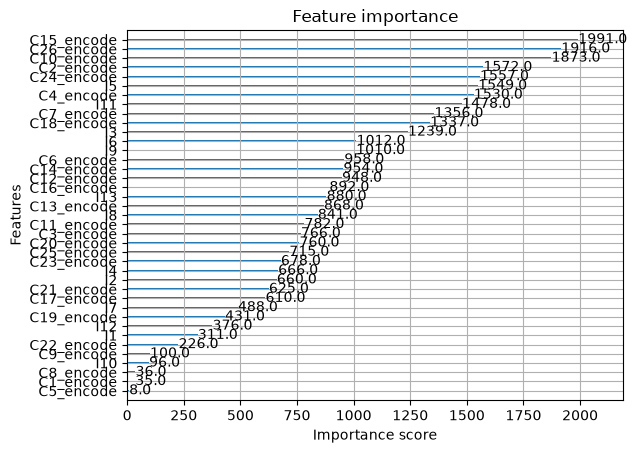

In [19]:
xgb.plot_importance(clf)

In [27]:
xgb.importance(clf)

AttributeError: module 'xgboost' has no attribute 'importance'

In [35]:
tree_df1.get_column('Node').describe(percentiles=[.1,.2,.3,.4,.5,.6,.7,.8,.9,.95,.99])

statistic,value
str,f64
"""count""",1.164887e6
"""null_count""",0.0
"""mean""",13675.728397
"""std""",14608.668261
"""min""",0.0
"""10%""",1010.0
"""20%""",2246.0
"""30%""",3820.0
"""40%""",5764.0


In [34]:
tree_df1.select('Cover').describe(percentiles=[.1,.2,.3,.4,.5,.6,.7,.8,.9])

statistic,Cover
str,f64
"""count""",1.164887e6
"""null_count""",0.0
"""mean""",4798.653604
"""std""",57069.717403
"""min""",1.000011
"""10%""",6.778203
"""20%""",23.555242
"""30%""",58.470745
"""40%""",121.945999


In [ ]:

clf.get_booster().save_config()

'{"learner":{"generic_param":{"device":"cpu","fail_on_invalid_gpu_id":"0","n_jobs":"0","nthread":"0","random_state":"0","rng_state":"0 1 1812433255 1900727105 1208447044 2481403966 4042607538 337614300 3232553940 1018809052 3202401494 1775180719 3192392114 594215549 184016991 829906058 610491522 3879932251 3139825610 297902587 4075895579 2943625357 3530655617 1423771745 2135928312 2891506774 1066338622 135451537 933040465 2759011858 2273819758 3545703099 2516396728 1272276355 3172048492 3267256201 2332199830 1975469449 392443598 1132453229 2900699076 1998300999 3847713992 512669506 1227792182 1629110240 112303347 2142631694 3647635483 1715036585 2508091258 1355887243 1884998310 3906360088 952450269 3647883368 3962623343 3077504981 2023096077 3791588343 3937487744 3455116780 1218485897 1374508007 2815569918 1367263917 472908318 2263147545 1461547499 4126813079 2383504810 64750479 2963140275 1709368606 4143643781 835933993 1881494649 674663333 2076403047 858036109 1667579889 1706666497 6

In [14]:
tree_df1.filter(pl.col('Tree')==0)

Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
i64,i64,str,str,f64,str,str,str,f64,f64,f64
0,0,"""0-0""","""I6""",16.0,"""0-1""","""0-2""","""0-2""",107371.938,349607.188,null
0,1,"""0-1""","""I6""",4.0,"""0-3""","""0-4""","""0-4""",14189.6641,95528.6328,null
0,2,"""0-2""","""I11""",2.0,"""0-5""","""0-6""","""0-5""",21986.3867,254078.562,null
0,3,"""0-3""","""I9""",4.0,"""0-7""","""0-8""","""0-8""",6026.70312,42744.5039,null
0,4,"""0-4""","""I11""",3.0,"""0-9""","""0-10""","""0-10""",6152.59375,52784.1328,null
0,5,"""0-5""","""I6""",147.0,"""0-11""","""0-12""","""0-12""",3978.47266,170580.281,null
0,6,"""0-6""","""I3""",7.0,"""0-13""","""0-14""","""0-13""",4676.54639,83498.2734,null
0,7,"""0-7""","""I13""",1.0,"""0-15""","""0-16""","""0-16""",971.106445,16596.2012,null
0,8,"""0-8""","""I5""",8.0,"""0-17""","""0-18""","""0-18""",2380.42969,26148.3008,null


Cover is the sum of Hessians

Gain is the split improvement score

$$Gain=\frac{1}{2}\left[\frac{G^2_L}{H_L+\lambda} +  \frac{G^2_R}{H_R+\lambda} - \frac{(G_L + G_R)^2}{H_L+H_R + \lambda}\right]-\gamma $$

In [10]:
95528.6328 + 254078.5620

349607.1948

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

import xgboost as xgb

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=94)

# Use "hist" for constructing the trees, with early stopping enabled.
clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2)
# Fit the model, test sets are used for early stopping.
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)])

[0]	validation_0-logloss:0.45881
[1]	validation_0-logloss:0.34098
[2]	validation_0-logloss:0.26923
[3]	validation_0-logloss:0.22191
[4]	validation_0-logloss:0.19087
[5]	validation_0-logloss:0.16534
[6]	validation_0-logloss:0.15061
[7]	validation_0-logloss:0.13786
[8]	validation_0-logloss:0.12966
[9]	validation_0-logloss:0.12204
[10]	validation_0-logloss:0.11153
[11]	validation_0-logloss:0.10982
[12]	validation_0-logloss:0.10507
[13]	validation_0-logloss:0.10309
[14]	validation_0-logloss:0.09874
[15]	validation_0-logloss:0.09633
[16]	validation_0-logloss:0.09424
[17]	validation_0-logloss:0.09407
[18]	validation_0-logloss:0.09504
[19]	validation_0-logloss:0.09318
[20]	validation_0-logloss:0.09308
[21]	validation_0-logloss:0.09144
[22]	validation_0-logloss:0.09112
[23]	validation_0-logloss:0.09131
[24]	validation_0-logloss:0.09086
[25]	validation_0-logloss:0.08889
[26]	validation_0-logloss:0.08848
[27]	validation_0-logloss:0.08843
[28]	validation_0-logloss:0.08737
[29]	validation_0-loglos

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",2
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [4]:
trees = pl.from_pandas(clf.get_booster().trees_to_dataframe())

In [3]:
import polars as pl

In [7]:
pl.Config.set_tbl_rows(100)

polars.config.Config

In [9]:
zz = trees.filter(pl.col("Tree")==0).sort("Node", descending=True)
zz

Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
i64,i64,str,str,f64,str,str,str,f64,f64,f64
0,20,"""0-20""","""Leaf""",null,null,null,null,0.335314,2.339318,null
0,19,"""0-19""","""Leaf""",null,null,null,null,0.029885,1.403591,null
0,18,"""0-18""","""Leaf""",null,null,null,null,0.11977,1.169659,null
0,17,"""0-17""","""Leaf""",null,null,null,null,0.464799,55.207897,null
0,16,"""0-16""","""Leaf""",null,null,null,null,-0.295042,1.169659,null
0,15,"""0-15""","""f16""",0.03137,"""0-19""","""0-20""","""0-20""",0.869482,3.742908,null
0,14,"""0-14""","""Leaf""",null,null,null,null,-0.018501,1.169659,null
0,13,"""0-13""","""f12""",4.099,"""0-17""","""0-18""","""0-18""",0.453842,56.377556,null
0,12,"""0-12""","""Leaf""",null,null,null,null,-0.777993,30.177198,null


In [10]:
zz.write_csv("tree.csv")

In [11]:
pwd

'/home/sean/Downloads'

In [12]:
clf.reg_lambda

In [13]:
clf.gamma

In [14]:
import json
tree_cfg = json.loads(clf.get_booster().save_config())

In [15]:
tree_cfg['learner']

{'generic_param': {'device': 'cpu',
  'fail_on_invalid_gpu_id': '0',
  'n_jobs': '0',
  'nthread': '0',
  'random_state': '0',
  'rng_state': '0 1 1812433255 1900727105 1208447044 2481403966 4042607538 337614300 3232553940 1018809052 3202401494 1775180719 3192392114 594215549 184016991 829906058 610491522 3879932251 3139825610 297902587 4075895579 2943625357 3530655617 1423771745 2135928312 2891506774 1066338622 135451537 933040465 2759011858 2273819758 3545703099 2516396728 1272276355 3172048492 3267256201 2332199830 1975469449 392443598 1132453229 2900699076 1998300999 3847713992 512669506 1227792182 1629110240 112303347 2142631694 3647635483 1715036585 2508091258 1355887243 1884998310 3906360088 952450269 3647883368 3962623343 3077504981 2023096077 3791588343 3937487744 3455116780 1218485897 1374508007 2815569918 1367263917 472908318 2263147545 1461547499 4126813079 2383504810 64750479 2963140275 1709368606 4143643781 835933993 1881494649 674663333 2076403047 858036109 1667579889 17

# Frequent Items

In [11]:
sample_every = 10
train_sample = pl.scan_parquet("~/projects/data/Criteo/train.parquet", row_index_name='Row').filter(pl.col('Row').mod(sample_every)==0)


In [12]:
n_cats = 26
cats = [f"C{i}" for i in range(1,n_cats+1)]

In [ ]:
train_sample.select([pl.col(f"I{d}").qcut(20, allow_duplicates=True).cast(pl.String).fill_null("NA") for d in range(1,14)]).collect() 

In [5]:
train_sample.head().collect()

Row,Label,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
0,0,0,6,6,6,421,109,1,7,107,0,1,null,6,"""05db9164""","""9b5fd12f""",null,null,"""4cf72387""",null,"""111121f4""","""0b153874""","""a73ee510""","""3b08e48b""","""ac9c2e8f""",null,"""6e2d6a15""","""07d13a8f""","""796a1a2e""",null,"""d4bb7bd8""","""8aaa5b67""",null,null,null,null,"""32c7478e""",null,null,null
1000,0,null,67,null,1,30202,null,null,23,null,null,null,null,22,"""68fd1e64""","""d833535f""","""77f2f2e5""","""d16679b9""","""25c83c98""","""7e0ccccf""","""8ce3a35f""","""0b153874""","""a73ee510""","""3b08e48b""","""c8e7f509""","""9f32b866""","""6e8ef725""","""b28479f6""","""a733d362""","""31ca40b6""","""776ce399""","""281769c2""",null,null,"""dfcfc3fa""",null,"""32c7478e""","""aee52b6f""",null,null
2000,1,null,1004,5,6,7146,null,0,21,71,null,0,null,6,"""68fd1e64""","""09e68b86""","""0f3acf4a""","""4d72b17e""","""cadb6f23""","""13718bbd""","""def88231""","""0b153874""","""a73ee510""","""3b08e48b""","""39b4a686""","""43bda269""","""11b529d9""","""07d13a8f""","""36721ddc""","""e42d74a2""","""e5ba7672""","""5aed7436""","""338f20de""","""b1252a9d""","""3dd939f7""",null,"""32c7478e""","""1f467519""","""3d2bedd7""","""9fc10a57"""
3000,0,0,124,null,0,84,35,101,4,252,0,8,null,0,"""05db9164""","""78ccd99e""","""870e08de""","""7dbb65fa""","""25c83c98""","""7e0ccccf""","""e773d3a8""","""0b153874""","""a73ee510""","""2407a361""","""5de52301""","""1f12da8c""","""510f15b3""","""b28479f6""","""1ca2ec64""","""aaf5306d""","""e5ba7672""","""e7e991cb""","""21ddcdc9""","""b1252a9d""","""e9313e1d""",null,"""bcdee96c""","""7a8852b0""","""cb079c2d""","""df09826b"""
4000,0,null,122,22,3,5101,null,0,10,16,null,0,null,3,"""05db9164""","""80e26c9b""","""8e8980b5""","""169ffff5""","""4cf72387""","""7e0ccccf""","""515fbe62""","""0b153874""","""a73ee510""","""3b08e48b""","""b0f4c8f5""","""b853b799""","""41777878""","""1adce6ef""","""8f92e3a1""","""5151f2ca""","""776ce399""","""1f9656b8""","""21ddcdc9""","""b1252a9d""","""38483e30""","""8ec974f4""","""be7c41b4""","""1793a828""","""e8b83407""","""70b6702c"""


In [13]:
items = (
    train_sample
    .select(["Label",*cats])
    .fill_null("missing")
    .select([pl.concat_str(pl.lit(cat),pl.col(cat),separator=":").alias(cat)  for cat in ["Label",*cats]])
)

In [17]:
items.head().collect()

Label,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""Label:0""","""C1:05db9164""","""C2:9b5fd12f""","""C3:missing""","""C4:missing""","""C5:4cf72387""","""C6:missing""","""C7:111121f4""","""C8:0b153874""","""C9:a73ee510""","""C10:3b08e48b""","""C11:ac9c2e8f""","""C12:missing""","""C13:6e2d6a15""","""C14:07d13a8f""","""C15:796a1a2e""","""C16:missing""","""C17:d4bb7bd8""","""C18:8aaa5b67""","""C19:missing""","""C20:missing""","""C21:missing""","""C22:missing""","""C23:32c7478e""","""C24:missing""","""C25:missing""","""C26:missing"""
"""Label:0""","""C1:68fd1e64""","""C2:d833535f""","""C3:77f2f2e5""","""C4:d16679b9""","""C5:25c83c98""","""C6:7e0ccccf""","""C7:8ce3a35f""","""C8:0b153874""","""C9:a73ee510""","""C10:3b08e48b""","""C11:c8e7f509""","""C12:9f32b866""","""C13:6e8ef725""","""C14:b28479f6""","""C15:a733d362""","""C16:31ca40b6""","""C17:776ce399""","""C18:281769c2""","""C19:missing""","""C20:missing""","""C21:dfcfc3fa""","""C22:missing""","""C23:32c7478e""","""C24:aee52b6f""","""C25:missing""","""C26:missing"""
"""Label:1""","""C1:68fd1e64""","""C2:09e68b86""","""C3:0f3acf4a""","""C4:4d72b17e""","""C5:cadb6f23""","""C6:13718bbd""","""C7:def88231""","""C8:0b153874""","""C9:a73ee510""","""C10:3b08e48b""","""C11:39b4a686""","""C12:43bda269""","""C13:11b529d9""","""C14:07d13a8f""","""C15:36721ddc""","""C16:e42d74a2""","""C17:e5ba7672""","""C18:5aed7436""","""C19:338f20de""","""C20:b1252a9d""","""C21:3dd939f7""","""C22:missing""","""C23:32c7478e""","""C24:1f467519""","""C25:3d2bedd7""","""C26:9fc10a57"""
"""Label:0""","""C1:05db9164""","""C2:78ccd99e""","""C3:870e08de""","""C4:7dbb65fa""","""C5:25c83c98""","""C6:7e0ccccf""","""C7:e773d3a8""","""C8:0b153874""","""C9:a73ee510""","""C10:2407a361""","""C11:5de52301""","""C12:1f12da8c""","""C13:510f15b3""","""C14:b28479f6""","""C15:1ca2ec64""","""C16:aaf5306d""","""C17:e5ba7672""","""C18:e7e991cb""","""C19:21ddcdc9""","""C20:b1252a9d""","""C21:e9313e1d""","""C22:missing""","""C23:bcdee96c""","""C24:7a8852b0""","""C25:cb079c2d""","""C26:df09826b"""
"""Label:0""","""C1:05db9164""","""C2:80e26c9b""","""C3:8e8980b5""","""C4:169ffff5""","""C5:4cf72387""","""C6:7e0ccccf""","""C7:515fbe62""","""C8:0b153874""","""C9:a73ee510""","""C10:3b08e48b""","""C11:b0f4c8f5""","""C12:b853b799""","""C13:41777878""","""C14:1adce6ef""","""C15:8f92e3a1""","""C16:5151f2ca""","""C17:776ce399""","""C18:1f9656b8""","""C19:21ddcdc9""","""C20:b1252a9d""","""C21:38483e30""","""C22:8ec974f4""","""C23:be7c41b4""","""C24:1793a828""","""C25:e8b83407""","""C26:70b6702c"""


In [14]:
items.sink_csv("train_sample_100_items.tsv", separator="\t")

In [20]:
!head train_sample_1000_items.tsv

Label	C1	C2	C3	C4	C5	C6	C7	C8	C9	C10	C11	C12	C13	C14	C15	C16	C17	C18	C19	C20	C21	C22	C23	C24	C25	C26
Label:0	C1:05db9164	C2:9b5fd12f	C3:missing	C4:missing	C5:4cf72387	C6:missing	C7:111121f4	C8:0b153874	C9:a73ee510	C10:3b08e48b	C11:ac9c2e8f	C12:missing	C13:6e2d6a15	C14:07d13a8f	C15:796a1a2e	C16:missing	C17:d4bb7bd8	C18:8aaa5b67	C19:missing	C20:missing	C21:missing	C22:missing	C23:32c7478e	C24:missing	C25:missing	C26:missing
Label:0	C1:68fd1e64	C2:d833535f	C3:77f2f2e5	C4:d16679b9	C5:25c83c98	C6:7e0ccccf	C7:8ce3a35f	C8:0b153874	C9:a73ee510	C10:3b08e48b	C11:c8e7f509	C12:9f32b866	C13:6e8ef725	C14:b28479f6	C15:a733d362	C16:31ca40b6	C17:776ce399	C18:281769c2	C19:missing	C20:missing	C21:dfcfc3fa	C22:missing	C23:32c7478e	C24:aee52b6f	C25:missing	C26:missing
Label:1	C1:68fd1e64	C2:09e68b86	C3:0f3acf4a	C4:4d72b17e	C5:cadb6f23	C6:13718bbd	C7:def88231	C8:0b153874	C9:a73ee510	C10:3b08e48b	C11:39b4a686	C12:43bda269	C13:11b529d9	C14:07d13a8f	C15:36721ddc	C16:e42d74a2	C17:e5ba7672	C18:5aed7436	C19:338f2

`eclat -tr -s10 -eclg -R appearances.txt train_sample_1000_items.tsv train_sample_1000_items.txt`

In [21]:
!eclat -tr  -eclg -c25 -R appearances.txt train_sample_10_items.tsv train_sample_10_associations.txt

eclat - find frequent item sets with the eclat algorithm
version 5.24 (2022.11.22)        (c) 2002-2022   Christian Borgelt
reading appearances.txt ... [1 item(s)] done [0.00s].
reading train_sample_10_items.tsv ... [4328865 item(s), 3667251 transaction(s)] done [15.49s].
filtering, sorting and recoding items ... [89 item(s)] done [1.12s].
sorting and reducing transactions ... [1995630/3667251 transaction(s)] done [2.06s].
finding frequent item sets ... done [3.04s].
writing train_sample_10_associations.txt ... [997 rule(s)] done [0.00s].


In [19]:
!eclat -ts -s-1000 train_sample_10_items.tsv train_sample_10_items.txt

eclat - find frequent item sets with the eclat algorithm
version 5.24 (2022.11.22)        (c) 2002-2022   Christian Borgelt
reading train_sample_10_items.tsv ... [4328865 item(s), 3667251 transaction(s)] done [15.60s].
filtering, sorting and recoding items ... [6512 item(s)] done [1.24s].
sorting and reducing transactions ... [3568893/3667251 transaction(s)] done [3.02s].
writing train_sample_10_items.txt ... [599202775 set(s)] done [82.44s].


```
C9:a73ee510 (89.7093)
C22:missing C9:a73ee510 (68.6181)
C22:missing (76.4138)
Label:0 C9:a73ee510 (65.3188)
Label:0 C22:missing C9:a73ee510 (50.8235)
Label:0 C22:missing (57.6457)
Label:0 (74.2651)
```

In [7]:
ar.shape

(997, 4)

In [ ]:
ff = parse_frequent("train_sample_1000_items.txt").sort("support",descending=True).head(30).collect()

In [68]:
ff["rules"][1]

<Expr ['[(col("C22")) == ("missing")]'] at 0x786C8AFE0950>

In [82]:
ar.shape

(997, 4)

In [12]:
ar_rules = {f"ar_{i}": ar_rule for i, ar_rule in enumerate(ar.get_column("rules").to_list())}

In [13]:
train_ = (
    pl.scan_parquet("/workspace/data/Criteo/train.parquet")
    .with_columns(cs.starts_with("C").fill_null("missing"))
    .with_columns(**ar_rules)
    .sink_parquet("/workspace/data/Criteo/train_assoc997_copy.parquet")
)

In [58]:
train_sample.group_by("C9").agg(pl.len()).collect()

C9,len
str,u32
"""7cc72ec2""",3770
"""a73ee510""",32900
"""a18233ea""",3
